In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Load the dataset
Salaries = pd.read_csv("/kaggle/input/salary-dataset-simple-linear-regression/Salary_dataset.csv")

# Display the first 5 rows
print(Salaries.head())

   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0


In [3]:
Salaries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 848.0 bytes


In [4]:
Salaries.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [5]:
Salaries.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

In [6]:
X = Salaries["YearsExperience"].values.reshape(-1, 1) # to make 2D array as linear regression expect more feature eith more samples
y = Salaries["Salary"]

# Display the first 5 rows
print(X)
print(y)

[[ 1.2]
 [ 1.4]
 [ 1.6]
 [ 2.1]
 [ 2.3]
 [ 3. ]
 [ 3.1]
 [ 3.3]
 [ 3.3]
 [ 3.8]
 [ 4. ]
 [ 4.1]
 [ 4.1]
 [ 4.2]
 [ 4.6]
 [ 5. ]
 [ 5.2]
 [ 5.4]
 [ 6. ]
 [ 6.1]
 [ 6.9]
 [ 7.2]
 [ 8. ]
 [ 8.3]
 [ 8.8]
 [ 9.1]
 [ 9.6]
 [ 9.7]
 [10.4]
 [10.6]]
0      39344.0
1      46206.0
2      37732.0
3      43526.0
4      39892.0
5      56643.0
6      60151.0
7      54446.0
8      64446.0
9      57190.0
10     63219.0
11     55795.0
12     56958.0
13     57082.0
14     61112.0
15     67939.0
16     66030.0
17     83089.0
18     81364.0
19     93941.0
20     91739.0
21     98274.0
22    101303.0
23    113813.0
24    109432.0
25    105583.0
26    116970.0
27    112636.0
28    122392.0
29    121873.0
Name: Salary, dtype: float64


In [7]:
X.shape

(30, 1)

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state = 50)

In [10]:
X_train.shape

(21, 1)

In [11]:
y_train.shape

(21,)

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
X_test

array([[ 5.4],
       [ 3.3],
       [10.4],
       [ 3.8],
       [ 6. ],
       [ 6.1],
       [ 9.1],
       [ 6.9],
       [10.6]])

In [15]:
y_test

17     83089.0
8      64446.0
28    122392.0
9      57190.0
18     81364.0
19     93941.0
25    105583.0
20     91739.0
29    121873.0
Name: Salary, dtype: float64

In [16]:
# Make predictions
y_pred=model.predict(X_test)
print("The predicted salery is", y_pred )

The predicted salery is [ 75248.33406252  54962.99817703 123546.75283749  59792.84005453
  81044.14431552  82010.11269102 110989.163956    89737.85969501
 125478.68958849]


In [17]:
# Make predictions
new_YearsExperience = np.array([[5.4]])
predicted_Salary =model.predict(new_YearsExperience)
print("The predicted salery is",predicted_Salary )

The predicted salery is [75248.33406252]


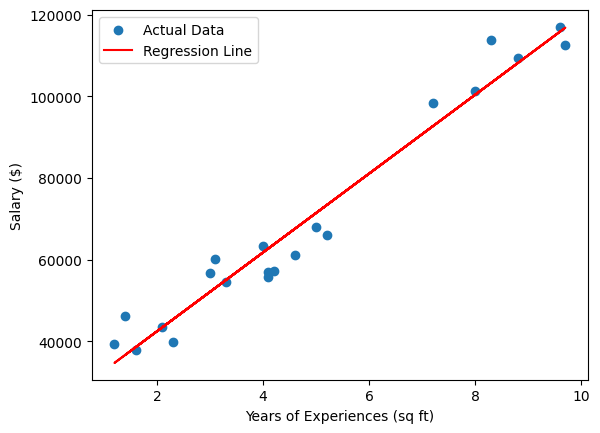

In [18]:
# Plot the data and the regression line
plt.scatter(X_train, y_train, label="Actual Data")
plt.plot(X_train, model.predict(X_train), color='red', label="Regression Line")
plt.xlabel("Years of Experiences (sq ft)")
plt.ylabel("Salary ($)")
plt.legend()
plt.show()

In [19]:
# Get the slope and intercept
print(f"Slope (m): {model.coef_[0]}")
print(f"Intercept (b): {model.intercept_}")

Slope (m): 9659.683754993344
Intercept (b): 23086.041785555753


In [20]:
from sklearn.metrics import mean_squared_error, r2_score
r2 = r2_score(y_test, y_pred)
print("R-squared Score:", r2)

R-squared Score: 0.9163676300745234
